# Random Forest

In [3]:
# Importar las librerias necesarias
from sklearn.ensemble import RandomForestRegressor      # Para el modelo RandomForest
from sklearn.model_selection import KFold, cross_validate       # Para la validacion usando el Kfold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score       # Para las metricas

In [4]:
# Se cargan las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [5]:
# Se cargan los datos en un dataframe
data = pd.read_csv("spotify_songs.csv")

In [6]:
# Separar datos para predecir

#primero se especifican las caracteristicas de cada cancion que se usaran para tratar de predecir la popularidad
caracteristicas = [
    'danceability',        # esta caracteristica dice que tan bailable es la cancion, entre 0 y 1
    'energy',              # representa la intensidad y actividad percibida de una canción
    'key',                 # representa la nota principal o centro tonal de una canción
    'loudness',            # volumen promedio de una canción medido en decibeles
    'mode',                # indica si una canción está compuesta en una escala mayor o menor
    'speechiness',         # mide la presencia de palabras habladas en una canción
    'acousticness',        # indica qué tan probable es que una canción sea acústica
    'instrumentalness',    # probabilidad de que una canción no contenga voces
    'liveness',            # probabilidad de que una canción haya sido grabada o interpretada en vivo frente a una audiencia
    'valence',             # describe el grado de positividad emocional que transmite una canción
    'tempo',               # velocidad o ritmo general de una canción y se mide en pulsaciones por minuto
    'duration_ms'          # La duración de la pista en milisegundos
]

# se crean dos conjuntos X e Y, en donde X es un dataset con las caracteristicas predictoras y el conjunto Y es la caracteristica a predecir
X = data[caracteristicas]
Y = data['track_popularity']

In [7]:
# crear y definir los hiperparametro del modelo RandomForest
modelo = RandomForestRegressor(n_estimators=300,        # cantidad de arboles a crear
                               max_depth=15,            # profundidad de cada arbol
                               min_samples_split=10,    # cantidad de canciones minimas para hacer una particion
                               min_samples_leaf=5,      # cantidad de canciones minimas para tomar una decisión (hoja)
                               random_state=1,          # para que sea cada ejecucion de la misma manera
                               n_jobs=-1)               # para usar todos los nucleos del sistema

# aca se define y se configura el Kfold para validar una buena prediccion
validacion = KFold(n_splits=5,      # 5 particiones
                   shuffle=True,    # para que se mezclen y no sean todas las muestras iguales
                   random_state=1)  # para que cada ejecucion sea igual

In [8]:
# metricas a utilizar para validar una buena prediccion
metricas = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error'
}

# aca se hace todo el trabajo, se hace una validacion usando al Kfold con el modelo definido arriba
# y se ven las metricas igualmente
resultados_cv = cross_validate(
    modelo, X, Y, 
    cv=validacion, 
    scoring=metricas, 
    return_train_score=True     # retorna el error del conjunto de entrenamiento
)

# mostrar el error de prediccion del conjunto de entrenamiento
print("Resultados en conjunto entrenamiento:")
print(f"R^2 promedio:   {np.mean(resultados_cv['train_r2']):.2f}")
print(f"MAE promedio:  {-np.mean(resultados_cv['train_mae']):.2f}")
print(f"RMSE promedio: {-np.mean(resultados_cv['train_rmse']):.2f}")
 
# mostrar el error de prediccion del conjunto de prueba
print("\n Resultados en conjunto prueba:")
print(f"R^2 promedio:   {np.mean(resultados_cv['test_r2']):.2f}")
print(f"MAE promedio:  {-np.mean(resultados_cv['test_mae']):.2f}")
print(f"RMSE promedio: {-np.mean(resultados_cv['test_rmse']):.2f}")

Resultados en conjunto entrenamiento:
R^2 promedio:   0.58
MAE promedio:  13.24
RMSE promedio: 16.15

 Resultados en conjunto prueba:
R^2 promedio:   0.24
MAE promedio:  18.01
RMSE promedio: 21.82


### Resultados
Luego de realizar el cross validation con 300 árboles y aplicar los parámetros de regularización para disminuir el overfitting (max_depth=15, min_samples_split=10, min_samples_leaf=5), se tiene lo siguiente:
1) Como primer punto tenemos el overfitting. Se logró controlar y disminuir para que el predictor no memorice el set de entrenamiento y pueda lograr una buena predicción en datos desconocidos. Se obtuvo un R^2 = 0.58 en el conjunto de entrenamiento y un R^2 = 0.24 en el conjunto de validación. Estos resultados muestran que el modelo sí es capaz de predecir datos no conocidos.
2) La razón de que el R^2 en el conjunto de validación sea de solo 0.24 (24%), indica que si bien el modelo es capaz de predecir la popularidad de una canción en base a sus atributos, no se puede predecir con certeza solo fijándose en esas características. Que una canción se vuelva conocida está basado en agentes externos como, por ejemplo: la popularidad del artista, el marketing de la canción o del álbum, que se haga trend en TikTok, entre otras.
3) Por último, las métricas MAE y RMSE tienen un valor de aproximadamente 18 y 21 puntos respectivamente. Estos valores indican que el modelo es estable y que no comete fallos de predicción con frecuencia.

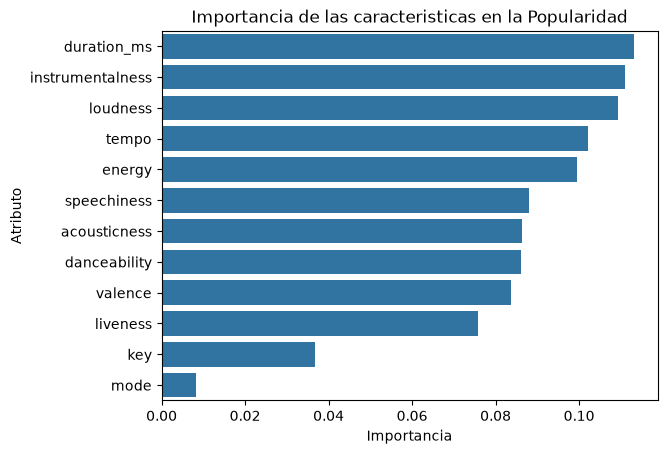

In [9]:
# entrenar el modelo con el 100% de los datos para sacar conclusiones finales
modelo.fit(X, Y)

# crear un dataframe con la importancia de cada variable de la cancion para luego graficar
importancias = pd.DataFrame({
    'Característica': caracteristicas,
    'Importancia': modelo.feature_importances_}).sort_values(by='Importancia', ascending=False)

# grafico para ver las caracteristicas mas relevantes para la popularidad de una cancion
sns.barplot(x='Importancia', y='Característica', data=importancias)
plt.title('Importancia de las caracteristicas en la Popularidad')
plt.xlabel('Importancia')
plt.ylabel('Atributo')
plt.show()

### Resultados
Analizando el gráfico de importancia de las características, podemos ver en que se fija el modelo al momento de predecir. Se observa claramente que las tres variables que más peso tienen son la duración de la canción (duration_ms), qué tan instrumental es (instrumentalness) y el volumen (loudness), lo que nos dice que la estructura básica de la pista y qué tan fuerte suena son la clave. En el medio tenemos atributos como el tempo, la energía o qué tan bailable es, que igual aportan a la predicción pero no marcan tanta diferencia como las tres primeras. Por último, al fondo del gráfico se ve que características como la nota principal (key) o si está en escala mayor o menor (mode), casi no le importan al predictor, lo que nos confirma empíricamente que a la gente le da lo mismo en qué nota exacta esté compuesta la canción a la hora de volverla un éxito.